In [ ]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 66.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 73.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 77.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [matplotlib]ow]

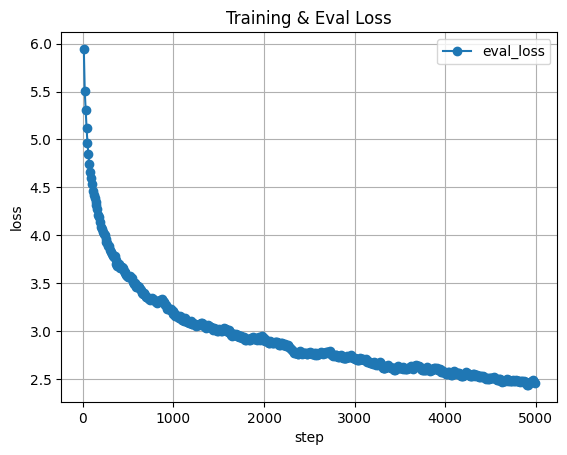

In [9]:
import re
import matplotlib.pyplot as plt

train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

with open('/Users/xuge/cs336/checkpoints/debug/training_log.txt') as f:
  for line in f:
      m = re.match(r'step=(\d+)\s+train_loss=([\d.]+)', line)
      if m:
          train_steps.append(int(m.group(1)))
          train_losses.append(float(m.group(2)))
          continue
      m = re.match(r'step=(\d+)\s+eval_loss=([\d.]+)', line)
      if m:
          eval_steps.append(int(m.group(1)))
          eval_losses.append(float(m.group(2)))

plt.plot(train_steps, train_losses, label='train_loss')
plt.plot(eval_steps, eval_losses, label='eval_loss', marker='o')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Training & Eval Loss')
plt.legend()
plt.grid(True)
plt.show()

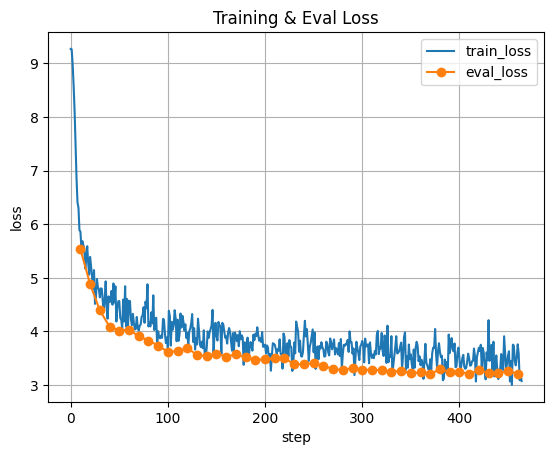

In [12]:
import re
import matplotlib.pyplot as plt

train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

with open('/Users/xuge/cs336/checkpoints/debug/438e2311-6f64-4957-866e-9cccbce88332/training_log.txt') as f:
  for line in f:
      m = re.match(r'step=(\d+)\s+train_loss=([\d.]+)', line)
      if m:
          train_steps.append(int(m.group(1)))
          train_losses.append(float(m.group(2)))
          continue
      m = re.match(r'step=(\d+)\s+eval_loss=([\d.]+)', line)
      if m:
          eval_steps.append(int(m.group(1)))
          eval_losses.append(float(m.group(2)))

plt.plot(train_steps, train_losses, label='train_loss')
plt.plot(eval_steps, eval_losses, label='eval_loss', marker='o')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Training & Eval Loss')
plt.legend()
plt.grid(True)
plt.show()

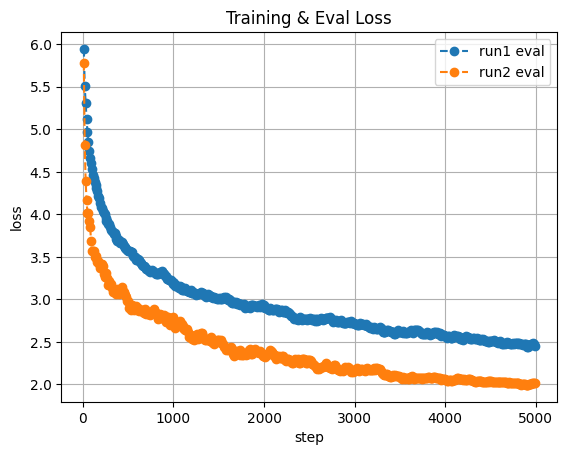

In [40]:
import re
import matplotlib.pyplot as plt

def parse_log(path):
  train_steps, train_losses = [], []
  eval_steps, eval_losses = [], []
  with open(path) as f:
      for line in f:
          m = re.match(r'step=(\d+)\s+train_loss=([\d.]+)', line)
          if m:
              train_steps.append(int(m.group(1)))
              train_losses.append(float(m.group(2)))
              continue
          m = re.match(r'step=(\d+)\s+eval_loss=([\d.]+)', line)
          if m:
              eval_steps.append(int(m.group(1)))
              eval_losses.append(float(m.group(2)))
  return train_steps, train_losses, eval_steps, eval_losses

runs = {
  'run1': '/Users/xuge/cs336/checkpoints/debug/training_log.txt',
  'run2': '/Users/xuge/cs336/checkpoints/debug/d1acf839-5ee1-48ed-b3d0-bf45237b7750/training_log.txt',
}

for i, (name, path) in enumerate(runs.items()):
  c = f'C{i % 10}'
  ts, tl, es, el = parse_log(path)
  # plt.plot(ts, tl, color=c, label=f'{name} train')
  plt.plot(es, el, color=c, linestyle='--', marker='o', label=f'{name} eval')

plt.xlabel('step')
plt.ylabel('loss')
plt.title('Training & Eval Loss')
plt.legend()
plt.grid(True)
plt.show()

Uv run python -m tests.train_together \
    --vocab_size 10000 \
    --context_length 256 \
    --d_model 512 \
    --d_ff 1344 \
    --num_layers 4 \
    --num_heads 16 \
    --rope_theta 10000 \
    --batch_size 32 \
    --eval_batch_size 2 \
    --num_steps 5000 \
    --log_interval 1 \
    --eval_interval 10 \
    --num_warmup_steps 5 \
    --cosine_cycle_iters 5000 \
    --max_lr 0.0015 \
    --min_lr 0.00015 \
    --device mps \
    --train_data ./tinystories_train.bin \
    --eval_data ./tinystories_valid.bin \
    --checkpoint_dir ./checkpoints/debug 

In [28]:
4 * 5000 * 256

5120000

In [31]:

327_680_000 / 512000

640.0

In [73]:
!Uv run python -m tests.decoding \
    --checkpoint ./checkpoints/debug/d1acf839-5ee1-48ed-b3d0-bf45237b7750/checkpoint_step_0005000.pt \
    --prompt "elene goes to a small hut"

torch.Size([1, 10000])
torch.Size([1])
torch.Size([8])
